In [1]:
import torch
import re, subprocess
import gc, re, os, hashlib
import numpy as np
import wandb
from scipy.special import softmax
from jax.tree_util import tree_map
from esmfold import ESMFold
import os, tarfile, urllib.request
import math
import matplotlib.pyplot as plt

In [2]:
OUT_DIR = "casp14_targets"
NUM_RECYCLES = 3 #["0", "1", "2", "3", "6", "12", "24"]
CHAIN_LINKER = 25

os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
## DOWNLOAD CASP14 DATASET
url = "https://predictioncenter.org/download_area/CASP14/targets/casp14.targets.T.public_11.29.2020.tar.gz"

tgz_path = os.path.join(OUT_DIR, os.path.basename(url))
if not os.path.exists(tgz_path):
    urllib.request.urlretrieve(url, tgz_path)

with tarfile.open(tgz_path, "r:gz") as tf:
    tf.extractall(OUT_DIR)

print("Extracted to:", OUT_DIR)

Extracted to: casp14_targets


/tmp/ipykernel_9005/1711440372.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(OUT_DIR)


In [4]:
from pathlib import Path

def read_fasta_to_dict(path):
    seqs = {}
    pdbs = {}
    name = None
    seq_chunks = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if name is not None and os.path.isfile(os.path.join(OUT_DIR, name + ".pdb")):
                    seqs[name] = "".join(seq_chunks)
                    pdbs[name] = os.path.join(OUT_DIR, name + ".pdb")
                name = line[1:].split()[0]   # e.g. T1024
                seq_chunks = []
            else:
                seq_chunks.append(line)
        if name is not None and os.path.isfile(os.path.join(OUT_DIR, name + ".pdb")):
            seqs[name] = "".join(seq_chunks)
            pdbs[name] = os.path.join(OUT_DIR, name + ".pdb")
            
    return seqs, pdbs

def compute_tm_score(pred_pdb, target_pdb, exe="./TMalign"):
    out = subprocess.check_output([exe, pred_pdb, target_pdb], text=True)
    m = re.search(r"TM-score\s*=\s*([0-9.]+)", out)
    if not m:
        raise RuntimeError("TM-score not found in TM-align output:\n" + out[:1000])
    return float(m.group(1))

In [5]:
## FOR OUTPUT VISUALIZATION

def parse_output(output):
    pae = (output["aligned_confidence_probs"][0] * np.arange(64)).mean(-1) * 31
    plddt = output["plddt"][0,:,1]
    
    bins = np.append(0,np.linspace(2.3125,21.6875,63))
    sm_contacts = softmax(output["distogram_logits"],-1)[0]
    sm_contacts = sm_contacts[...,bins<8].sum(-1)
    xyz = output["positions"][-1,0,:,1]
    mask = output["atom37_atom_exists"][0,:,1] == 1
    o = {"pae":pae[mask,:][:,mask],
         "plddt":plddt[mask],
         "sm_contacts":sm_contacts[mask,:][:,mask],
         "xyz":xyz[mask]}
    return o

In [6]:
## GARBAGE COLLECTION

gc.collect()
torch.cuda.empty_cache()

In [7]:
## LOAD MODEL AND TRANSFER WEIGHTS
pretrained = torch.load("esmfold.model", weights_only=False)
model = ESMFold(esmfold_config=pretrained.cfg) ## make copy of model with new forward pass and then transfer the weights
model.load_state_dict(pretrained.state_dict())
model = torch.compile(
    model,
    mode="reduce-overhead", 
)
model.eval().cuda().requires_grad_(False)

del pretrained
gc.collect()
torch.cuda.empty_cache()

chunk_size = 128
model.set_chunk_size(chunk_size)

In [8]:
## LOAD DATASET 
seqs, pdbs = read_fasta_to_dict("casp14_seq.txt")

In [9]:
def predict(sequence):
    def get_hash(x): return hashlib.sha1(x.encode()).hexdigest()
    ID ="test_"+get_hash(sequence)[:5]
    
    # Ensure profiler is clean before starting
    model.profiler.reset()
    
    wandb.init(
        project="esmfold-experiments",
        name=f"compile-{ID}",
        settings=wandb.Settings(silent=True),
        group="compile-casp14", 
        config={
            "sequence": sequence,
            "num_recycles": NUM_RECYCLES,
            "chunk_size": chunk_size,
            "length": len(sequence),
        }
    )
    
    output_gpu = model.infer(sequence,
                             num_recycles=NUM_RECYCLES,
                             residue_index_offset=512)
    
    for k, v in model.profiler.timings.items():
        wandb.log({k: sum(model.profiler.timings[k])})
    
    wandb.finish()

    total_time = model.profiler.timings["total_forward"][0]
    pdb_str = model.output_to_pdb(output_gpu)[0]
    
    output = tree_map(lambda x: x.cpu().numpy(), output_gpu)
    del output_gpu
    torch.cuda.empty_cache()
    gc.collect()
    
    ptm = output["ptm"][0]
    plddt = output["plddt"][0,...,1].mean()
    O = parse_output(output)
    
    os.system(f"mkdir -p {ID}")
    prefix = f"{ID}/ptm{ptm:.3f}_r{NUM_RECYCLES}_default"
    np.savetxt(f"{prefix}.pae.txt",O["pae"],"%.3f")
    with open(f"{prefix}.pdb","w") as out:
        out.write(pdb_str)
    
    percents_result = model.profiler.percents()
    
    del output, pdb_str, O
    gc.collect()
    torch.cuda.empty_cache()
    
    return ptm, plddt, percents_result, f"{prefix}.pdb", total_time

In [10]:
GROUPS = ["INPUT_EMBEDDING","BIAS_AND_MLP","TRIANGULAR_MULTIPLICATION","TRIANGULAR_ATTENTION","STRUCTURE_MODULE"]

rows = []
for k,seq in seqs.items():
    if len(seq) < 2000:
        ptm, plddt, percents, pred_pdb, total_time = predict(seq)
        tm = compute_tm_score(pred_pdb, pdbs[k])
        d = dict(percents)
        vals = [d.get(g, math.nan) for g in GROUPS]        
        rows.append((k, len(seq), ptm, plddt, tm, total_time, vals))
        print(k)
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    
pct = lambda v: f"{v:.2f}%" if v==v else "nan"
wk = max(len("k"),   *(len(str(r[0])) for r in rows))
wl = max(len("len"), *(len(str(r[1])) for r in rows))
wg = [max(len(g), *(len(pct(r[6][i])) for r in rows)) for i,g in enumerate(GROUPS)]
hdr = f"{'k':<{wk}}  {'len':>{wl}}  {'ptm':>7}  {'plddt':>8}  {'tm':>8}  {'tt':>8}  " + "  ".join(f"{g:>{w}}" for g,w in zip(GROUPS,wg))
print(hdr)
for k,L,ptm,plddt,tm,tt,vals in rows:
    print(f"{k:<{wk}}  {L:>{wl}}  {ptm:7.4f}  {plddt:8.4f}  {tm:8.4f}  {tt:8.3f}  " +
          "  ".join(f"{pct(v):>{w}}" for v,w in zip(vals,wg)))

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


T1024
T1025
T1026
T1027
T1029
T1030
T1031
T1032
T1033
T1035
T1036s1
T1037
T1038
T1039
T1040
T1041
T1042
T1043
T1046s1
T1046s2
T1049
T1050
T1054
T1056
T1064
T1067
T1073
T1074
T1079
T1080
T1082
T1090
T1099
k        len      ptm     plddt        tm        tt  INPUT_EMBEDDING  BIAS_AND_MLP  TRIANGULAR_MULTIPLICATION  TRIANGULAR_ATTENTION  STRUCTURE_MODULE
T1024    408   0.9530   94.3247    0.9114  6086.577            3.33%         8.84%                     26.20%                54.63%             5.19%
T1025    268   0.9388   93.5263    0.9118  2217.450            1.12%        12.12%                     24.98%                52.28%             8.13%
T1026    172   0.6769   73.1035    0.8091  1078.455            2.85%        13.80%                     23.80%                40.34%            16.67%
T1027    168   0.3962   47.2241    0.5196  1054.821            2.55%        14.01%                     23.85%                39.47%            17.53%
T1029    125   0.3544   45.4685    0.4988   83

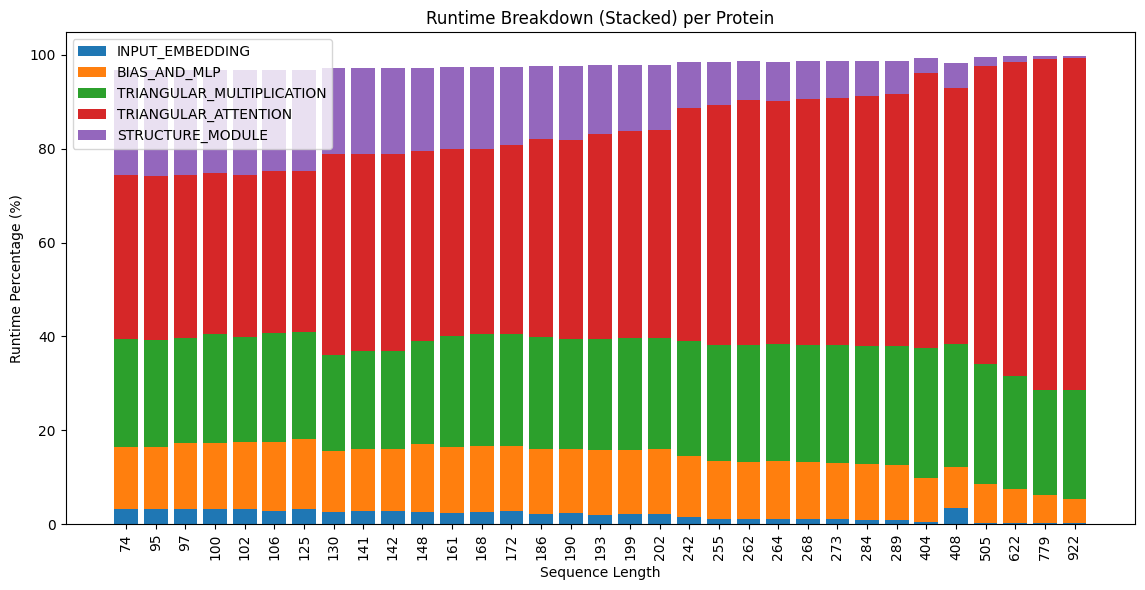

In [11]:
# Sort by sequence length so the bars are in increasing L
rows_sorted = sorted(rows, key=lambda r: r[1])
ks      = [r[0] for r in rows_sorted]
lengths = [r[1] for r in rows_sorted]

# Build group->values (percent) aligned to rows_sorted
group_vals = {g: [] for g in GROUPS}
for r in rows_sorted:
    vals = r[6]  # [pct per group]
    for g, v in zip(GROUPS, vals):
        group_vals[g].append(0.0 if (v != v) else float(v))  # NaN -> 0 for stacking

x = np.arange(len(rows_sorted))

plt.figure(figsize=(max(10, 0.35 * len(rows_sorted)), 6))

bottom = np.zeros(len(rows_sorted), dtype=float)
for g in GROUPS:
    y = np.array(group_vals[g], dtype=float)
    plt.bar(x, y, bottom=bottom, label=g)
    bottom += y

plt.ylabel("Runtime Percentage (%)")
plt.title("Runtime Breakdown (Stacked) per Protein")
plt.xticks(x, [str(L) for L in lengths], rotation=90)  # show lengths on x-axis
plt.xlabel("Sequence Length")
plt.legend()
plt.tight_layout()
plt.show()

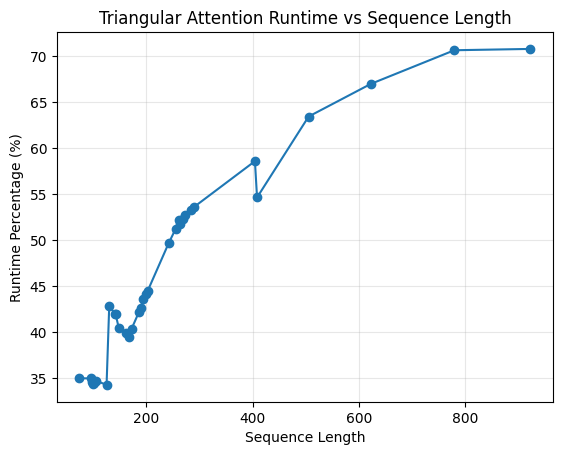

In [12]:
g_idx = GROUPS.index("TRIANGULAR_ATTENTION")

# Sort by sequence length
rows_sorted = sorted(rows, key=lambda r: r[1])

lengths = []
tri_attn_pct = []

for _, L, _, _, _, _,vals in rows_sorted:
    v = vals[g_idx]
    if v == v:  # skip NaNs
        lengths.append(L)
        tri_attn_pct.append(v)

plt.figure()
plt.plot(lengths, tri_attn_pct, marker="o")

plt.xlabel("Sequence Length")
plt.ylabel("Runtime Percentage (%)")
plt.title("Triangular Attention Runtime vs Sequence Length")
plt.grid(True, alpha=0.3)
plt.show()

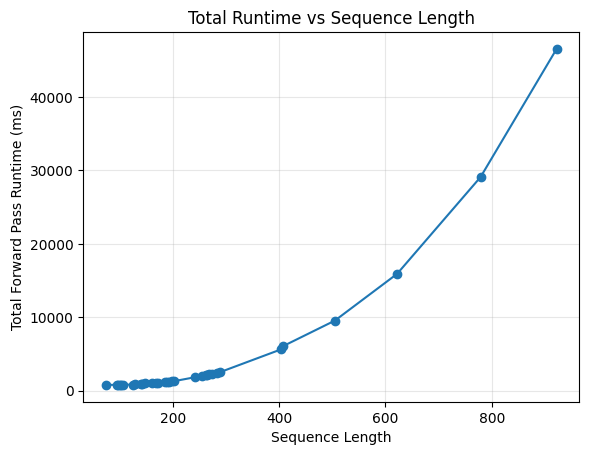

In [13]:
rows_sorted = sorted(rows, key=lambda r: r[1])

lengths = [r[1] for r in rows_sorted]
total_times = [r[5] for r in rows_sorted]

plt.figure()
plt.plot(lengths, total_times, marker="o")

plt.xlabel("Sequence Length")
plt.ylabel("Total Forward Pass Runtime (ms)")
plt.title("Total Runtime vs Sequence Length")
plt.grid(True, alpha=0.3)
plt.show()